## Dataset Composition Analysis
This notebook provides a comprehensive analysis of the dataset composition.


In [2]:
# Library imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter
from pathlib import Path
from collections import Counter

# Visualization settings
plt.rcParams['figure.figsize'] = (12, 8)
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

### General Dataset Analysis

This section provides an overview of the complete dataset composition. Specific analyses for each split (train, validation, test) will be performed later.

#### 1. Data Loading and Processing


In [3]:
def load_dataset_info(file_path='../build/files.txt'):
    """
    Loads dataset information from files.txt
    
    Args:
        file_path (str): Path to the files.txt file
    
    Returns:
        pandas.DataFrame: DataFrame with file information
    """
    
    # Class mapping
    class_mapping = {
        '000001': 'S.stercoralis',
        '000002': 'Impurities'
    }
    
    # List to store data
    data = []
    
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            for line in file:
                filename = line.strip()
                if filename:  # Skip empty lines
                    # Extract class and ID from filename
                    # Expected format: class_id.extension
                    name_parts = filename.split('_')
                    if len(name_parts) >= 2:
                        class_code = name_parts[0]
                        id_with_ext = name_parts[1]
                        id_num = id_with_ext.split('.')[0]
                        extension = filename.split('.')[-1] if '.' in filename else ''
                        
                        # Map class code to class name using class_mapping
                        class_code = class_code.replace('images/', '')
                        class_name = class_mapping.get(class_code, f'Unknown_Class_{class_code}')
                        
                        data.append({
                            'filename': filename,
                            'class_code': class_code,
                            'class_name': class_name,
                            'id': id_num,
                            'extension': extension
                        })
    
    except FileNotFoundError:
        print(f"File {file_path} not found!")
        return pd.DataFrame()
    
    df = pd.DataFrame(data)
    print(f"Dataset loaded successfully! Total of {len(df)} files.")
    return df

# Load data
df = load_dataset_info('../build/files.txt')

Dataset loaded successfully! Total of 3514 files.


#### 2. Initial Exploratory Analysis

In [4]:
# Basic dataset information
print("=== GENERAL DATASET INFORMATION ===")
print(f"Total files: {len(df)}")
print(f"Number of unique classes: {df['class_name'].nunique()}")
print(f"Extensions found: {df['extension'].unique()}")

# Check for duplicates
duplicates = df.duplicated(subset=['filename']).sum()
print(f"Duplicate files: {duplicates}")

# Statistics by class
print("\n=== STATISTICS BY CLASS ===")
class_stats = df.groupby('class_name').agg({
    'id': ['count', 'nunique'],
    'extension': lambda x: ', '.join(x.unique())
}).round(2)

class_stats.columns = ['Total_Files', 'Unique_IDs', 'Extensions']
print(class_stats)

=== GENERAL DATASET INFORMATION ===
Total files: 3514
Number of unique classes: 2
Extensions found: ['png']
Duplicate files: 0

=== STATISTICS BY CLASS ===
               Total_Files  Unique_IDs Extensions
class_name                                       
Impurities            3068        3068        png
S.stercoralis          446         446        png


#### 3. Visualizations

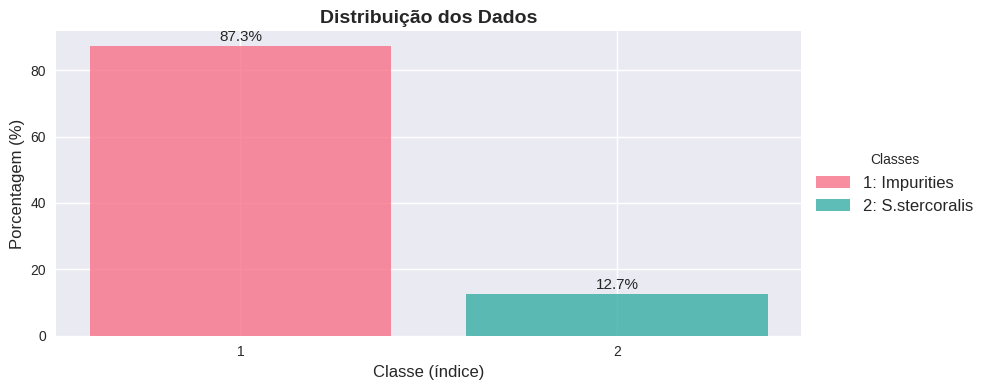

In [5]:
# Count files by class
class_counts = df['class_name'].value_counts()

# Calculate the percentage of each class
class_percent = class_counts / class_counts.sum() * 100

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(len(class_percent)), class_percent.values, color=sns.color_palette("husl", len(class_percent)), alpha=0.8)

ax.set_title('Distribuição dos Dados', fontsize=14, fontweight='bold')
ax.set_xlabel('Classe (índice)', fontsize=12)
ax.set_ylabel('Porcentagem (%)', fontsize=12)
ax.set_xticks(range(len(class_percent)))
ax.set_xticklabels([f'{i+1}' for i in range(len(class_percent))], rotation=0)

# Add values above the bars
for i, v in enumerate(class_percent.values):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=11)

# Add legend with full class names, prefixed with C1...C9
legend_labels = [f'{i+1}: {name}' for i, name in enumerate(class_percent.index)]
ax.legend(bars, legend_labels, title="Classes", loc="center left", bbox_to_anchor=(1, 0.5), fontsize=12)

plt.tight_layout()
plt.show()


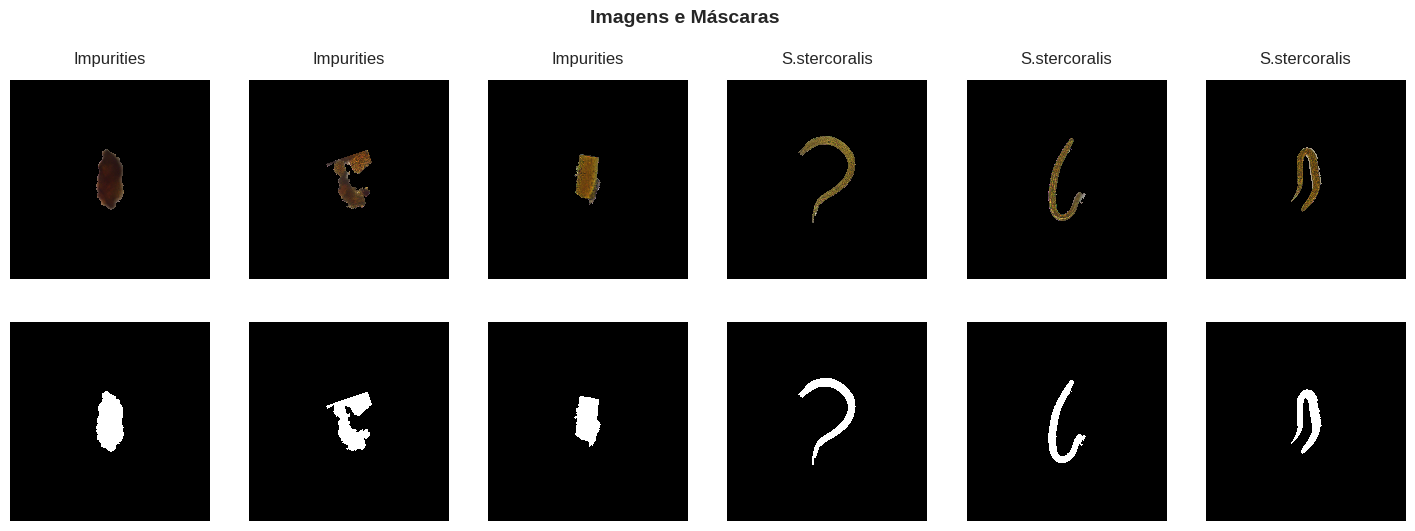

In [8]:
# Select one random filename for each class
random_filenames = df.groupby('class_name')['filename'].apply(lambda x: x.sample(3, random_state=123)).reset_index(drop=True)

images_dir = Path('../build/images')
masks_dir = Path('../build/masks')

images = []
masks = []

for filename in random_filenames:
    # Remove 'images/' prefix from filename
    filename = filename.replace('images/', '')
    image_path = images_dir / filename
    mask_path = masks_dir / filename

    # Check if both image and mask files exist
    if image_path.exists() and mask_path.exists():
        images.append(plt.imread(image_path))
        masks.append(plt.imread(mask_path))
    else:
        print(f"Missing file: {image_path} or {mask_path}")

# Display images and masks
num_cols = len(images)
fig, axes = plt.subplots(2, num_cols, figsize=(3 * num_cols, 6))

# Increase spacing between images
plt.subplots_adjust(wspace=0.2, hspace=0.1)

fig.suptitle("Imagens e Máscaras", fontsize=14, fontweight='bold')

for i, (image, mask) in enumerate(zip(images, masks)):
    # Show image
    axes[0, i].imshow(image)
    axes[0, i].axis('off')

    # Show mask
    axes[1, i].imshow(mask, cmap='gray')
    axes[1, i].axis('off')

    # Get class name for current image
    class_name = df.loc[df['filename'] == random_filenames.iloc[i], 'class_name'].values[0]
    axes[0, i].set_title(class_name, fontsize=12, pad=12)

# Use tight_layout() to adjust overall spacing, but manual adjustment is preferred here
# plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
# Get basic information about image shapes and sizes
image_shapes = [img.shape for img in images]
unique_shapes = set(image_shapes)

print("=== IMAGE SIZE INFORMATION ===")
print(f"Total images loaded: {len(images)}")
print(f"Unique image shapes: {unique_shapes}")

# If all images have the same shape, show width and height
if len(unique_shapes) == 1:
    h, w = image_shapes[0][:2]
    print(f"All images have the same size: {w} x {h} pixels")
else:
    print("Images have varying sizes. Here are the counts for each shape:")
    shape_counts = Counter(image_shapes)
    for shape, count in shape_counts.items():
        print(f"Shape {shape}: {count} images")

#### Splits

In [ ]:
# Directory containing split files
splits_dir = Path('../build/splits')
split_files = ['train1.csv', 'test1.csv', 'train2.csv', 'test2.csv', 'train3.csv', 'test3.csv']

split_distributions = {}

for split_file in split_files:
    split_path = splits_dir / split_file
    if split_path.exists():
        split_df = load_dataset_info(split_path)
        class_dist = split_df['class_name'].value_counts()
        split_distributions[split_file] = class_dist
    else:
        print(f"Split file not found: {split_path}")

# Display class distribution for each split
for split_name, dist in split_distributions.items():
    print(f"\n=== Class Distribution in {split_name} ===")
    print(dist)

In [ ]:
# Calculate percentage distribution for each split and compare with full dataset
full_dist = class_counts / class_counts.sum() * 100

for split_name, dist in split_distributions.items():
    split_percent = dist / dist.sum() * 100
    print(f"\n=== Class Distribution in {split_name} ===")
    # print(dist)
    # print("\nPercentage distribution:")
    # print(split_percent.round(2))
    print("\nComparison with full dataset (%):")
    comparison = pd.DataFrame({
        'Split (%)': split_percent.round(2),
        'Full Dataset (%)': full_dist.round(2),
        'Difference (%)': (split_percent - full_dist).round(2)
    })
    print(comparison)
